# NBA Offensive Archetype Clustering

**Question:** Can NBA players be grouped into offensive archetypes based only on their shot profile, and do the clusters line up with the roles analysts already use (rim-running centers, three-point specialists, shot creators, mid-range scorers, balanced offensive players)?

**Approach:** Unsupervised clustering on shot-profile features pulled live from `nba_api`.

**Setup:** `pip install nba_api`. the API calls need internet access to `stats.nba.com`.

**Sections**
1. Setup & imports
2. Data collection (live `nba_api` pull)
3. Data cleaning
4. Feature engineering
5. Preprocessing (scaling)
6. Choosing the number of clusters
7. Clustering
8. Cluster evaluation & visualization
9. Comparing clusters to known archetypes
9b. Naming the clusters
10. Export for the website


## 1. Setup & Imports

In [30]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42

pd.set_option("display.max_columns", 50)


## 2. Data Collection

**Sources (via `nba_api`):**
- `leaguedashplayershotlocations`: FGA/FGM/FG_PCT by zone: Restricted Area, In The Paint (Non-RA), Mid-Range, Left/Right Corner 3, Above the Break 3.

- `playerdashboardbyshootingsplits` (`assisted_by`): per-player assisted FG makes, summed across assisting teammates.

- `leaguedashplayerstats`: per-game PTS/REB/AST for the bio panel (not used in clustering).

The API calls are a lot and, as you can see below in the cell output, take awhile. I wrote it so that it creates a CSV upon first collection of data in order to avoid recalling it everytime the notebook gets run again.

**Output schema (`raw_df`), one row per player:**
- `player_id`, `player_name`: kept aside, not used as clustering features

- `fga_rim`, `fga_paint_non_ra`, `fga_midrange`, `fga_corner3`, `fga_above_break3`: attempts by zone

- `fgm_rim`, `fgm_paint_non_ra`, `fgm_midrange`, `fgm_corner3`, `fgm_above_break3`: makes by zone

- `assisted_fgm`, `unassisted_fgm`: approximate makes by assist status

- `total_fga`: total attempts, used to filter low-volume players


In [31]:
import time
from pathlib import Path
from nba_api.stats.endpoints import (
    leaguedashplayershotlocations,
    leaguedashplayerstats,
    playerdashboardbyshootingsplits,
)

# Will occasionally time out or rate-limit. Re-run a cell if a single request fails

SEASON = "2025-26" # Extension: doing past seasons, aggregating the data to build out a player's CAREER archetype. 
SEASON_TYPE = "Regular Season"
CACHE_PATH = Path(f"shot_data_{SEASON.replace('-', '_')}.csv")


def _with_retries(fn, retries=3, delay=3, label="request"):
    last_error = None

    for attempt in range(1, retries + 1):
        try:
            return fn()
        except Exception as e:
            last_error = e
            print(f"{label} failed (attempt {attempt}/{retries}): {type(e).__name__}: {e}")

            if attempt < retries:
                time.sleep(delay * attempt)

    raise RuntimeError(
        f"{label} failed after {retries} attempts. "
        f"Last error: {type(last_error).__name__}: {last_error}"
    ) from last_error


def _fetch_shot_locations(season: str, season_type: str) -> pd.DataFrame:
    """Fetch zone-level shooting data from NBA.com."""

    def call():
        resp = leaguedashplayershotlocations.LeagueDashPlayerShotLocations(
            season=season,
            season_type_all_star=season_type,
            distance_range="By Zone",
            per_mode_detailed="Totals",
            measure_type_simple="Base",
            timeout=60,
        )
        return resp.get_dict()

    raw = _with_retries(call, label="Shot location fetch")

    result_set = raw["resultSets"]
    headers = result_set["headers"]
    rows = result_set["rowSet"]

    # NBA.com gives us the actual column count
    actual_columns = headers[1]["columnNames"]

    print(f"API returned {len(actual_columns)} columns")
    print(f"First row contains {len(rows[0])} values")

    # The first 5 columns are player information
    base_cols = actual_columns[:5]
    metric_cols = actual_columns[5:]

    zone_names = headers[0]["columnNames"]
    column_span = headers[0]["columnSpan"]

    flat_cols = list(base_cols)

    for i, metric in enumerate(metric_cols):
        zone_index = i // column_span

        if zone_index < len(zone_names):
            zone = zone_names[zone_index]
            flat_cols.append(f"{zone}__{metric}")
        else:
            # Preserve unexpected API columns instead of crashing
            flat_cols.append(metric)

    # Safety check
    if len(flat_cols) != len(rows[0]):
        raise RuntimeError(
            f"Could not map NBA shot-location columns correctly: "
            f"{len(flat_cols)} names for {len(rows[0])} values."
        )

    return pd.DataFrame(rows, columns=flat_cols)


def _fetch_assist_splits(
    player_ids,
    season: str,
    season_type: str,
) -> pd.DataFrame:
    """
    Fetch season-level assisted field-goal makes for each player.

    PlayerDashboardByShootingSplits.assisted_by is a BREAKDOWN BY ASSISTING
    TEAMMATE, not a single per-player total — a player who got baskets from
    10 different teammates over the season comes back as 10 rows, each with
    that teammate's FGM count. Fixed by summing FGM across all of a player's 
    assisting-teammate rows first, so each player contributes exactly one 
    row. That sum represents their true total assisted-FGM count.
    """

    results = []

    for i, player_id in enumerate(player_ids, start=1):
        def call():
            resp = playerdashboardbyshootingsplits.PlayerDashboardByShootingSplits(
                player_id=int(player_id),
                measure_type_detailed="Base",
                per_mode_detailed="Totals",
                season=season,
                season_type_playoffs=season_type,
                timeout=60,
            )

            return resp.assisted_by.get_data_frame()

        try:
            df = _with_retries(
                call,
                label=f"Assist-split fetch {player_id}",
            )

            if df.empty:
                print(f"[{i}/{len(player_ids)}] No assist data for {player_id}")
                continue

            df["FGM"] = pd.to_numeric(df["FGM"], errors="coerce")
            assisted_fgm = df["FGM"].sum()

            results.append(pd.DataFrame({
                "PLAYER_ID": [player_id],
                "assisted_fgm": [assisted_fgm],
            }))

            print(
                f"[{i}/{len(player_ids)}] Fetched {player_id} "
                f"({len(df)} assisting teammates -> {assisted_fgm:.0f} assisted FGM)"
            )

        except Exception as e:
            print(f"[{i}/{len(player_ids)}] Skipping {player_id}: {e}")

        time.sleep(0.25)

    if not results:
        raise RuntimeError("No assisted/unassisted shooting data was fetched.")

    out = pd.concat(results, ignore_index=True)
    assert out["PLAYER_ID"].is_unique, (
        "Assist-split aggregation still produced duplicate players — "
        "investigate before merging."
    )
    return out


def _fetch_basic_box_score(season: str, season_type: str) -> pd.DataFrame:
    """Per-game PTS/REB/AST — just for the "bio" panel on the website card,
    not used as clustering features."""

    def call():
        resp = leaguedashplayerstats.LeagueDashPlayerStats(
            season=season,
            season_type_all_star=season_type,
            per_mode_detailed="PerGame",
            measure_type_detailed_defense="Base",
            timeout=60,
        
        )
        return resp.get_data_frames()[0]

    df = _with_retries(call, label="Box score fetch")
    return df[["PLAYER_ID", "PTS", "REB", "AST"]].rename(
        columns={"PTS": "ppg", "REB": "rpg", "AST": "apg"}
    )


def load_shot_data(season: str = SEASON, season_type: str = SEASON_TYPE,
                    use_cache: bool = True) -> pd.DataFrame:
    """
    Real loader: pulls zone shot data, assist splits, team, and basic box
    score from nba_api and shapes them into the schema the rest of the
    notebook expects. This is the function that caches to a CSV to avoid
    repeated API calls.
    """

    if use_cache and CACHE_PATH.exists():
        cached = pd.read_csv(CACHE_PATH)
        if cached["player_id"].is_unique:
            print(f"Loading cached shot data from {CACHE_PATH}")
            return cached
        print(
            f"{CACHE_PATH} has duplicate player_id rows (written before a "
            f"dedup fix, most likely) — deleting it and re-fetching fresh data."
        )
        CACHE_PATH.unlink()

    shot_df = _fetch_shot_locations(season, season_type)

    def zval(zone, metric):
        return pd.to_numeric(shot_df[f"{zone}__{metric}"], errors="coerce")

    out = pd.DataFrame({
        "player_id": shot_df["PLAYER_ID"],
        "player_name": shot_df["PLAYER_NAME"],
        "team": shot_df["TEAM_ABBREVIATION"],
        "fga_rim": zval("Restricted Area", "FGA"),
        "fgm_rim": zval("Restricted Area", "FGM"),
        "fga_paint_non_ra": zval("In The Paint (Non-RA)", "FGA"),
        "fgm_paint_non_ra": zval("In The Paint (Non-RA)", "FGM"),
        "fga_midrange": zval("Mid-Range", "FGA"),
        "fgm_midrange": zval("Mid-Range", "FGM"),
    })
    out["fga_corner3"] = zval("Left Corner 3", "FGA") + zval("Right Corner 3", "FGA")
    out["fgm_corner3"] = zval("Left Corner 3", "FGM") + zval("Right Corner 3", "FGM")
    out["fga_above_break3"] = zval("Above the Break 3", "FGA")
    out["fgm_above_break3"] = zval("Above the Break 3", "FGM")
    out["total_fga"] = out[[c for c in out.columns if c.startswith("fga_")]].sum(axis=1)

    # Total makes across zones: used below to derive unassisted_fgm
    out["total_fgm"] = out[
        ["fgm_rim", "fgm_paint_non_ra", "fgm_midrange", "fgm_corner3", "fgm_above_break3"]
    ].sum(axis=1)

    # Assisted makes (aggregated per player: see _fetch_assist_splits)
    pt_df = _fetch_assist_splits(
        shot_df["PLAYER_ID"].dropna().unique(),
        season,
        season_type,
    )

    assert out["player_id"].is_unique, (
        "raw shot-location data has duplicate players before merging assist data — investigate"
    )

    out = out.merge(
        pt_df,
        left_on="player_id",
        right_on="PLAYER_ID",
        how="left",
    ).drop(columns=["PLAYER_ID"])

    out["assisted_fgm"] = out["assisted_fgm"].fillna(0)
    out["unassisted_fgm"] = (out["total_fgm"] - out["assisted_fgm"]).clip(lower=0)

    overcounted = (out["assisted_fgm"] > out["total_fgm"]).sum()
    if overcounted:
        print(
            f"Warning: {overcounted} player(s) have assisted_fgm > total_fgm — "
            "the assisted-by breakdown may include something unexpected for them; "
            "worth spot-checking those rows."
        )

    assert out["player_id"].is_unique, (
        "Merge introduced duplicate players — investigate source tables"
    )

    # Bio panel stats (not used in clustering)
    box_df = _fetch_basic_box_score(season, season_type)
    out = out.merge(box_df, left_on="player_id", right_on="PLAYER_ID", how="left").drop(
        columns=["PLAYER_ID"]
    )

    if use_cache:
        out.to_csv(CACHE_PATH, index=False)
        print(f"Cached shot data to {CACHE_PATH}")

    return out


raw_df = load_shot_data()
raw_df.head()


Loading cached shot data from shot_data_2025_26.csv


,player_id,player_name,team,fga_rim,fgm_rim,fga_paint_non_ra,fgm_paint_non_ra,fga_midrange,fgm_midrange,fga_corner3,fgm_corner3,fga_above_break3,fgm_above_break3,total_fga,total_fgm,assisted_fgm,unassisted_fgm,ppg,rpg,apg
0,1630639,A.J. Lawson,TOR,27,14,6,1,0,0,32.0,14.0,13,5,78.0,34.0,33.0,1.0,4.2,1.8,0.3
1,1631260,AJ Green,MIL,19,11,19,10,26,9,152.0,74.0,402,158,618.0,262.0,236.0,26.0,10.4,2.7,1.9
2,1642358,AJ Johnson,DAL,77,33,38,12,4,0,11.0,3.0,46,9,176.0,57.0,25.0,32.0,3.3,1.1,1.0
3,203932,Aaron Gordon,DEN,129,97,62,20,50,20,46.0,20.0,111,41,398.0,198.0,140.0,58.0,16.2,5.8,2.7
4,1628988,Aaron Holiday,HOU,22,13,44,21,16,4,53.0,25.0,117,42,252.0,105.0,72.0,33.0,5.5,1.0,1.1


## 3. Data Cleaning

The average/median FGA for a player in a season is 464.15/387.5, respectively. We'll use 200 to be inclusive.

The number can be changed, but lower introduces more noise, and higher excludes more players.

In [32]:
MIN_FGA = 200

df = raw_df.copy()
print("Before filtering:", df.shape)

df = df[df["total_fga"] >= MIN_FGA].reset_index(drop=True)
print("After filtering (min FGA):", df.shape)

df.isna().sum()


Before filtering: (582, 20)
After filtering (min FGA): (350, 20)


player_id           0
player_name         0
team                0
fga_rim             0
fgm_rim             0
fga_paint_non_ra    0
fgm_paint_non_ra    0
fga_midrange        0
fgm_midrange        0
fga_corner3         0
fgm_corner3         0
fga_above_break3    0
fgm_above_break3    0
total_fga           0
total_fgm           0
assisted_fgm        0
unassisted_fgm      0
ppg                 0
rpg                 0
apg                 0
dtype: int64

## 4. Feature Engineering

Convert raw counts to rate-based features so players are compared on shot profile (the shape of their shot selection and efficiency) rather than raw volume:

- Zone frequency shares: `pct_fga_rim`, `pct_fga_paint`, `pct_fga_midrange`, `pct_fga_corner3`, `pct_fga_above_break3`

- Zone efficiency: `fgpct_rim`, `fgpct_paint`, `fgpct_midrange`, `fgpct_corner3`, `fgpct_above_break3`

- Shot-selection aggregates: `three_point_rate`, `rim_plus_three_rate`, `midrange_rate`

- Shot creation: `pct_assisted`, `pct_unassisted`

Week 1 features:

- `shot_diversity`: normalized Shannon entropy across the five shot zones. Measures how broadly a player distributes their shot attempts.

- `unassisted_fga_rate`: unassisted field goals divided by total FGA

Extension: Tracking-data features (touch time, dribbles per touch, contested vs. open shots) can be incorporated once available in the API


In [33]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    zones = ["rim", "paint_non_ra", "midrange", "corner3", "above_break3"]

    # Frequency shares
    for z in zones:
        out[f"pct_fga_{z}"] = out[f"fga_{z}"] / out["total_fga"]

    # Zone efficiency (raw FG%)
    for z in zones:
        with np.errstate(divide="ignore", invalid="ignore"):
            out[f"fgpct_{z}"] = np.where(out[f"fga_{z}"] > 0, out[f"fgm_{z}"] / out[f"fga_{z}"], np.nan)

    # Aggregate shot-selection metrics
    out["three_point_rate"] = (out["fga_corner3"] + out["fga_above_break3"]) / out["total_fga"]
    out["rim_plus_three_rate"] = (out["fga_rim"] + out["fga_corner3"] + out["fga_above_break3"]) / out["total_fga"]
    out["midrange_rate"] = out["fga_midrange"] / out["total_fga"]

    # Shot creation
    total_fgm = out[[f"fgm_{z}" for z in zones]].sum(axis=1)
    out["pct_assisted"] = out["assisted_fgm"] / total_fgm.replace(0, np.nan)
    out["pct_unassisted"] = out["unassisted_fgm"] / total_fgm.replace(0, np.nan)

    # W1 Add: Shot diversity: normalized Shannon entropy across shot zones
    shot_shares = out[[f"pct_fga_{z}" for z in zones]].clip(lower=1e-12)
    out["shot_diversity"] = (
        -(shot_shares * np.log(shot_shares)).sum(axis=1)
        / np.log(len(zones))
    )

    # W1 Add: Unassisted scoring relative to total shot volume
    out["unassisted_fga_rate"] = (
        out["unassisted_fgm"] / out["total_fga"]
    )

    return out

features_df = engineer_features(df)

# Fill NaN zone-efficiency values (e.g. zero attempts in a zone) with the column median
fgpct_cols = [c for c in features_df.columns if c.startswith("fgpct_")]
features_df[fgpct_cols] = features_df[fgpct_cols].fillna(features_df[fgpct_cols].median())

features_df[["player_name"] + fgpct_cols + ["three_point_rate", "rim_plus_three_rate", "pct_assisted"]].head()


,player_name,fgpct_rim,fgpct_paint_non_ra,fgpct_midrange,fgpct_corner3,fgpct_above_break3,three_point_rate,rim_plus_three_rate,pct_assisted
0,AJ Green,0.578947,0.526316,0.346154,0.486842,0.393035,0.896440,0.927184,0.900763
1,Aaron Gordon,0.751938,0.322581,0.400000,0.434783,0.369369,0.394472,0.718593,0.707071
2,Aaron Holiday,0.590909,0.477273,0.250000,0.471698,0.358974,0.674603,0.761905,0.685714
3,Aaron Nesmith,0.526316,0.397590,0.421053,0.437500,0.355330,0.541016,0.726562,0.886792
4,Aaron Wiggins,0.602649,0.388889,0.360000,0.369048,0.349462,0.503731,0.785448,0.679654


## 5. Preprocessing

Select the feature columns that go into clustering then standardize, since K-Means and similar methods are sensitive to feature scale.

ID/name goes out


In [34]:
FEATURE_COLS = [
    "pct_fga_rim", "pct_fga_paint_non_ra", "pct_fga_midrange", "pct_fga_corner3", "pct_fga_above_break3",
    "fgpct_rim", "fgpct_paint_non_ra", "fgpct_midrange", "fgpct_corner3", "fgpct_above_break3",
    "pct_assisted",
    "shot_diversity", "unassisted_fga_rate"
]

X = features_df[FEATURE_COLS].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=FEATURE_COLS, index=features_df.index)
X_scaled_df.describe().T[["mean", "std", "min", "max"]]


,mean,std,min,max
pct_fga_rim,-1.015061e-17,1.001432,-1.720603,4.032054
pct_fga_paint_non_ra,1.268826e-17,1.001432,-2.201229,4.510575
pct_fga_midrange,-2.030122e-17,1.001432,-1.247488,5.579210
pct_fga_corner3,2.486900e-16,1.001432,-1.432863,3.926439
pct_fga_above_break3,-2.030122e-16,1.001432,-1.969829,2.475534
fgpct_rim,-4.288633e-16,1.001432,-3.463472,2.723698
fgpct_paint_non_ra,-2.144316e-16,1.001432,-4.798974,6.398468
fgpct_midrange,1.344956e-16,1.001432,-3.082136,4.899460
fgpct_corner3,6.648650e-16,1.001432,-3.057448,4.931853
fgpct_above_break3,7.866723e-17,1.001432,-3.633175,7.319507


## 5b. Testing Week 1 Audits

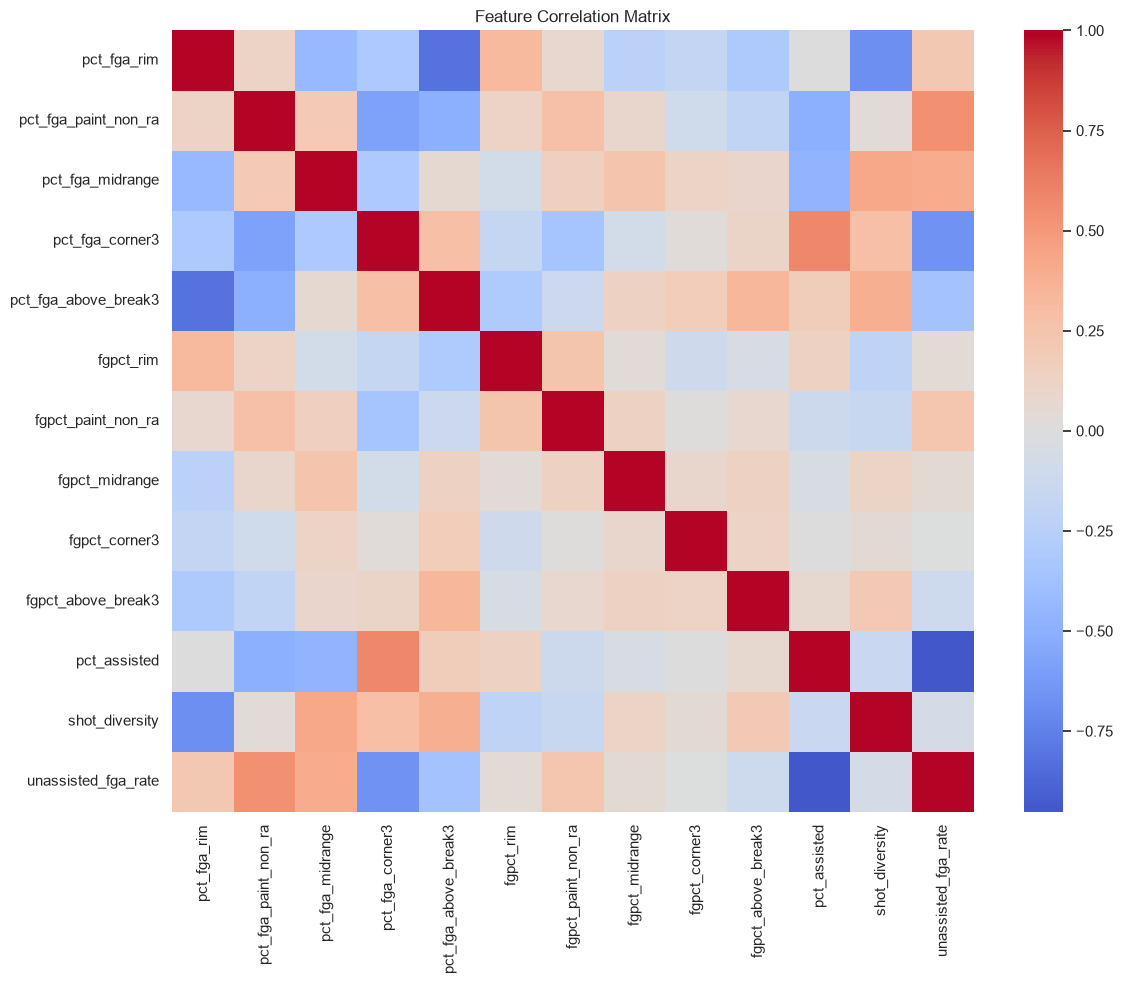

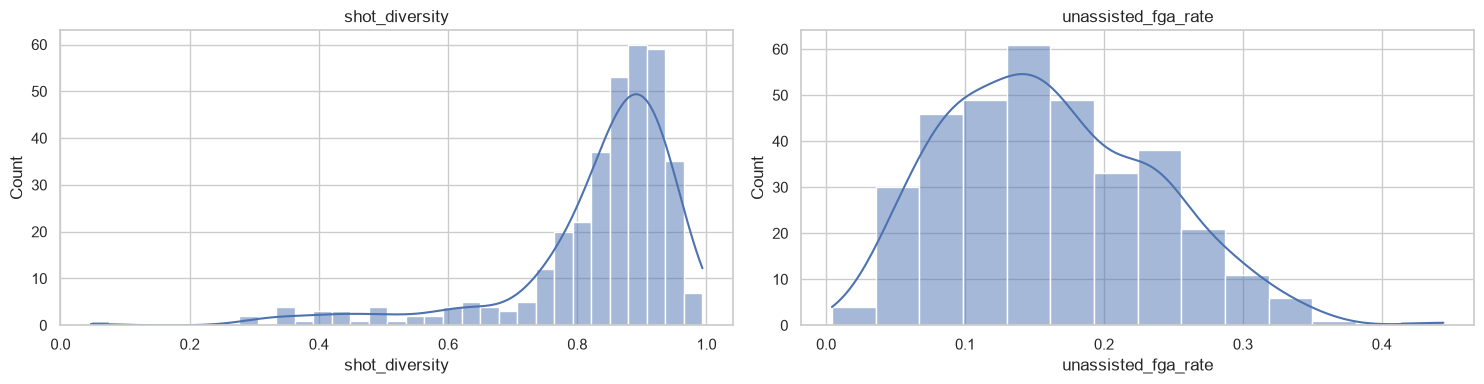

In [35]:
plt.figure(figsize=(12, 10))

corr = features_df[FEATURE_COLS].corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=False
)

plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

audit = pd.DataFrame({
    "mean": features_df[FEATURE_COLS].mean(),
    "std": features_df[FEATURE_COLS].std(),
    "skew": features_df[FEATURE_COLS].skew(),
    "min": features_df[FEATURE_COLS].min(),
    "max": features_df[FEATURE_COLS].max(),
})

audit.sort_values("skew", key=lambda x: x.abs(), ascending=False)

NEW_FEATURES = [
    "shot_diversity",
    "unassisted_fga_rate",
]

fig, axes = plt.subplots(1, len(NEW_FEATURES), figsize=(15, 4))

for ax, feature in zip(axes, NEW_FEATURES):
    sns.histplot(features_df[feature], kde=True, ax=ax)
    ax.set_title(feature)
    ax.set_xlabel(feature)

plt.tight_layout()
plt.show()

## 6. Choosing the Number of Clusters

Elbow method (inertia) and silhouette score across a range of `k` values. 
The choice of `k` is inherently subjective. The plots inform it but don't settle it.


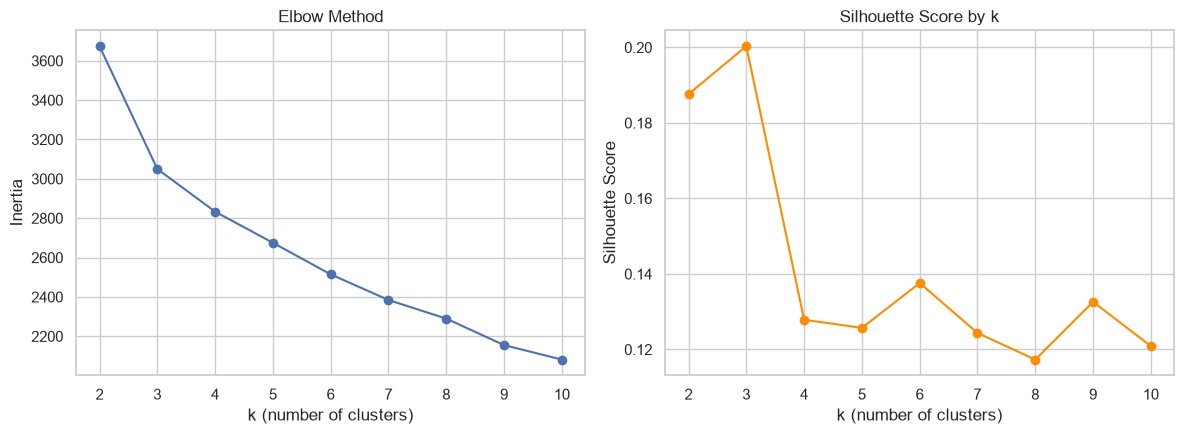

In [37]:
k_range = range(2, 11)
inertias = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(list(k_range), inertias, marker="o")
axes[0].set_xlabel("k (number of clusters)")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Method")

axes[1].plot(list(k_range), silhouettes, marker="o", color="darkorange")
axes[1].set_xlabel("k (number of clusters)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score by k")

plt.tight_layout()
plt.show()


## 7. Clustering

Fit K-Means with a chosen `k`, then fit Gaussian Mixture and Agglomerative clustering on the same data as alternatives for comparison. Update `N_CLUSTERS` based on Section 6 and domain judgment.


In [38]:
N_CLUSTERS = 5  # chosen from Section 6 + domain judgment

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=10)
features_df["cluster_kmeans"] = kmeans.fit_predict(X_scaled)

# Alternative algorithms for later robustness comparison
gmm = GaussianMixture(n_components=N_CLUSTERS, random_state=RANDOM_STATE)
features_df["cluster_gmm"] = gmm.fit_predict(X_scaled)

agglo = AgglomerativeClustering(n_clusters=N_CLUSTERS)
features_df["cluster_agglo"] = agglo.fit_predict(X_scaled)

features_df["cluster_kmeans"].value_counts().sort_index()


cluster_kmeans
0     57
1    109
2     83
3     60
4     41
Name: count, dtype: int64

## 8. Cluster Evaluation & Visualization

- Quantitative: silhouette score and Davies-Bouldin index for the chosen K-Means solution.
- Visual: project the scaled features into 2D via PCA and plot the clusters, plus a heatmap of average feature values per cluster to interpret what each cluster represents.


Silhouette score: 0.126
Davies-Bouldin index: 1.781  (lower is better)


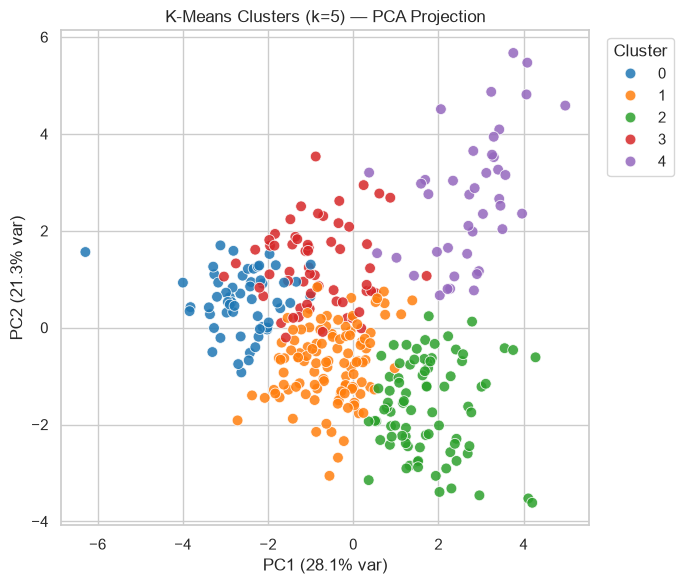

In [39]:
sil = silhouette_score(X_scaled, features_df["cluster_kmeans"])
db = davies_bouldin_score(X_scaled, features_df["cluster_kmeans"])
print(f"Silhouette score: {sil:.3f}")
print(f"Davies-Bouldin index: {db:.3f}  (lower is better)")

pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_coords = pca.fit_transform(X_scaled)
features_df["pca_1"], features_df["pca_2"] = pca_coords[:, 0], pca_coords[:, 1]

plt.figure(figsize=(7, 6))
sns.scatterplot(
    data=features_df, x="pca_1", y="pca_2",
    hue="cluster_kmeans", palette="tab10", s=60, alpha=0.85,
)
plt.title(f"K-Means Clusters (k={N_CLUSTERS}) — PCA Projection")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var)")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


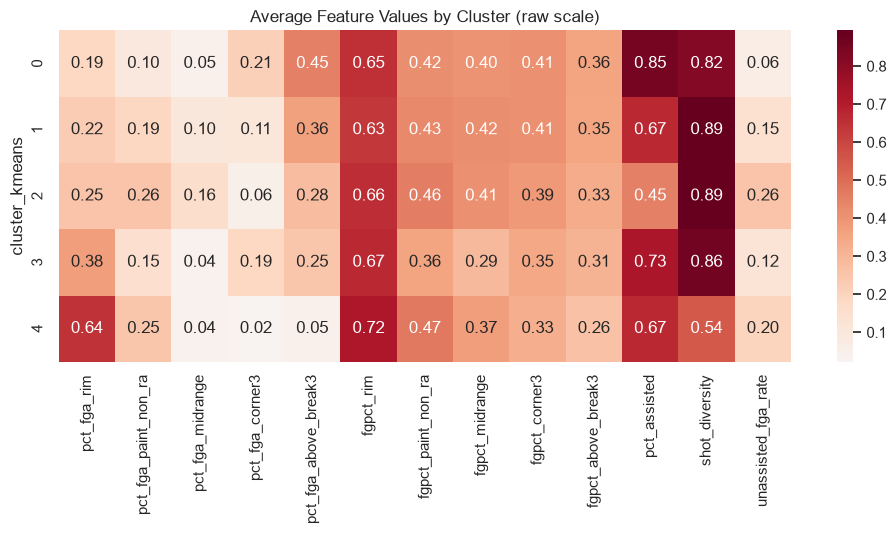

,pct_fga_rim,pct_fga_paint_non_ra,pct_fga_midrange,pct_fga_corner3,pct_fga_above_break3,fgpct_rim,fgpct_paint_non_ra,fgpct_midrange,fgpct_corner3,fgpct_above_break3,pct_assisted,shot_diversity,unassisted_fga_rate
cluster_kmeans,,,,,,,,,,,,,
0,0.187174,0.098734,0.049432,0.212845,0.451815,0.654927,0.419401,0.401637,0.409164,0.359900,0.850783,0.816016,0.064831
1,0.224207,0.193751,0.104202,0.113824,0.364015,0.631411,0.433327,0.416883,0.405116,0.354347,0.672142,0.893678,0.145174
2,0.254456,0.258129,0.156286,0.055923,0.275205,0.659900,0.459780,0.409993,0.387673,0.332964,0.452697,0.886902,0.256328
3,0.375882,0.152516,0.039364,0.186493,0.245745,0.670307,0.357673,0.294030,0.348526,0.309047,0.729723,0.856539,0.124525
4,0.644894,0.247600,0.036177,0.022276,0.049052,0.716724,0.469307,0.369502,0.326196,0.263011,0.673251,0.544097,0.197529


In [40]:
cluster_profile = features_df.groupby("cluster_kmeans")[FEATURE_COLS].mean()

plt.figure(figsize=(10, 4 + 0.3 * N_CLUSTERS))
sns.heatmap(cluster_profile, annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Average Feature Values by Cluster (raw scale)")
plt.tight_layout()
plt.show()

cluster_profile

## 8b. New Feature Validation

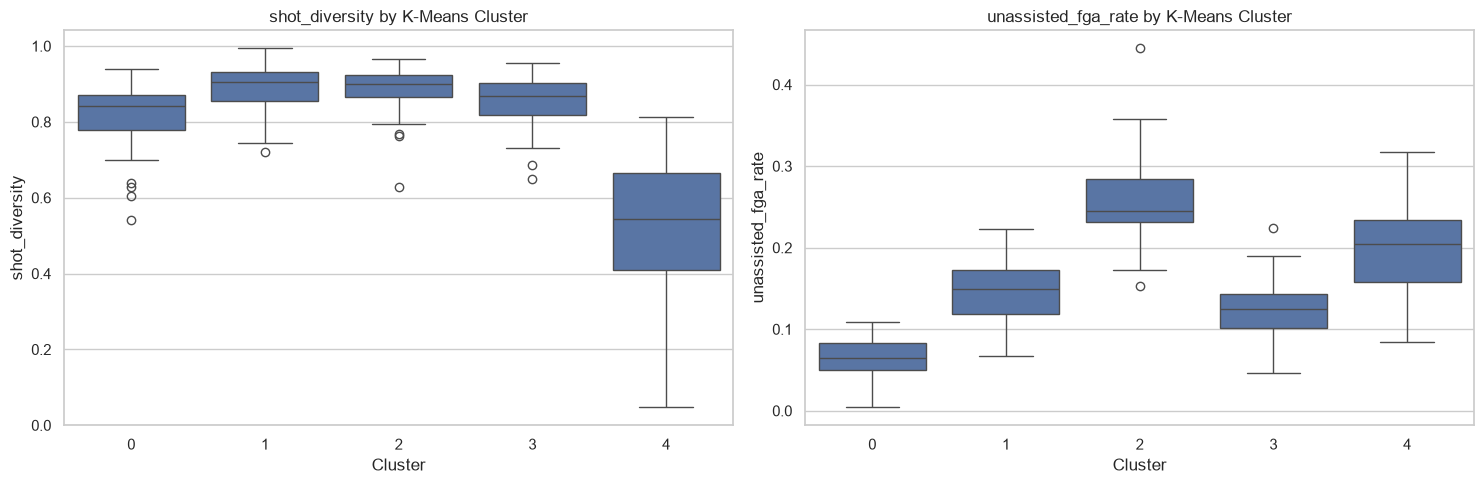

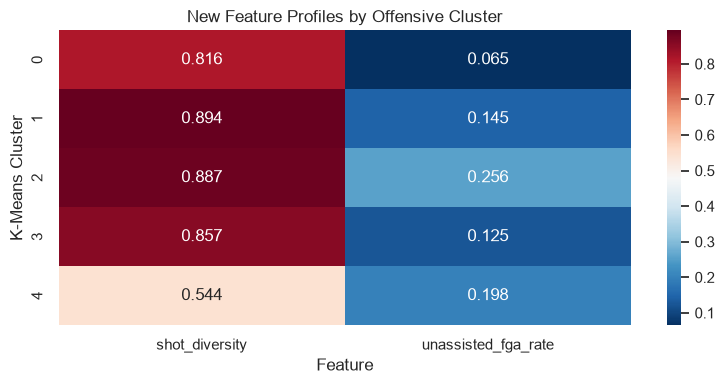

shot_diversity: F=147.40, p=2.406e-73
unassisted_fga_rate: F=240.07, p=2.645e-98


In [41]:
fig, axes = plt.subplots(1, len(NEW_FEATURES), figsize=(15, 5))

for ax, feature in zip(axes, NEW_FEATURES):
    sns.boxplot(
        data=features_df,
        x="cluster_kmeans",
        y=feature,
        ax=ax
    )
    ax.set_title(f"{feature} by K-Means Cluster")
    ax.set_xlabel("Cluster")

plt.tight_layout()
plt.show()

new_feature_profile = (
    features_df
    .groupby("cluster_kmeans")[NEW_FEATURES]
    .mean()
    .round(3)
)

new_feature_profile

plt.figure(figsize=(8, 4))

sns.heatmap(
    new_feature_profile,
    annot=True,
    fmt=".3f",
    cmap="RdBu_r",
    center=new_feature_profile.values.mean()
)

plt.title("New Feature Profiles by Offensive Cluster")
plt.xlabel("Feature")
plt.ylabel("K-Means Cluster")
plt.tight_layout()
plt.show()

from scipy.stats import f_oneway

for feature in NEW_FEATURES:
    groups = [
        group[feature].dropna().values
        for _, group in features_df.groupby("cluster_kmeans")
    ]

    stat, p = f_oneway(*groups)

    print(
        f"{feature}: "
        f"F={stat:.2f}, p={p:.4g}"
    )

## 9. Comparing Clusters to Known Archetypes

Compare the discovered clusters to analyst-assigned archetypes:

- Cross-tabulate clusters against a reference archetype label set (confusion-matrix style) once one exists.
- Spot-check well-known players per cluster to see whether the grouping "makes basketball sense."
- Treat surprising groupings as findings rather than errors — players don't always fit their expected role.

The real data has no reference labels, so the cell below just prints a note; this section gets filled in by hand.


In [42]:
if "true_archetype_for_reference_only" in features_df.columns:
    comparison = pd.crosstab(
        features_df["true_archetype_for_reference_only"],
        features_df["cluster_kmeans"],
    )
    display(comparison)
else:
    print(
        "Use the cluster_profile heatmap above (and the player spot-checks "
        "below) to decide what each cluster number actually represents."
    )


Use the cluster_profile heatmap above (and the player spot-checks below) to decide what each cluster number actually represents.


In [43]:
# Spot-check a few players per cluster
for c in sorted(features_df["cluster_kmeans"].unique()):
    sample = features_df.loc[features_df["cluster_kmeans"] == c, "player_name"].head(5).tolist()
    print(f"Cluster {c}: {sample}")


Cluster 0: ['AJ Green', 'Aaron Nesmith', 'Al Horford', 'Alex Caruso', 'Baylor Scheierman']
Cluster 1: ['Aaron Gordon', 'Aaron Holiday', 'Aaron Wiggins', 'Ace Bailey', 'Alex Sarr']
Cluster 2: ['Ajay Mitchell', 'Alperen Sengun', 'Andrew Nembhard', 'Anfernee Simons', 'Anthony Davis']
Cluster 3: ['Andre Drummond', 'Anthony Black', 'Ben Saraf', 'Bilal Coulibaly', 'Bruce Brown']
Cluster 4: ['Adem Bona', 'Amen Thompson', 'Anthony Gill', 'Ausar Thompson', 'Clint Capela']


## 9b. Naming the Clusters

K-Means returns cluster numbers, not names. We have to turn `cluster_kmeans == 3` into "Rim Runner" manually. I used the `cluster_profile` heatmap from Section 8 and the spot-checks above: high `pct_fga_rim` and `fgpct_rim` = rim runner; high `three_point_rate` and low `pct_assisted` = shot creator; and so on so forth.

`CLUSTER_NAMES` can be changed to whatever. Cluster numbers aren't stable across refits, so redoing this cell by eye on every retrain might be necessary.

In [44]:
CLUSTER_NAMES = {
    0: "Balanced Wing", # slightly inaccurate, Curry is labeled under this cluster
    1: "Midrange Scorer",
    2: "Three-and-D",
    3: "Rim Runner",
    4: "Shot Creator",
}

missing = set(features_df["cluster_kmeans"].unique()) - set(CLUSTER_NAMES)
if missing:
    raise ValueError(f"CLUSTER_NAMES is missing an entry for cluster(s): {missing}")

features_df["archetype"] = features_df["cluster_kmeans"].map(CLUSTER_NAMES)
features_df[["player_name", "cluster_kmeans", "archetype"]].head(10)


,player_name,cluster_kmeans,archetype
0,AJ Green,0,Balanced Wing
1,Aaron Gordon,1,Midrange Scorer
2,Aaron Holiday,1,Midrange Scorer
3,Aaron Nesmith,0,Balanced Wing
4,Aaron Wiggins,1,Midrange Scorer
5,Ace Bailey,1,Midrange Scorer
6,Adem Bona,4,Shot Creator
7,Ajay Mitchell,2,Three-and-D
8,Al Horford,0,Balanced Wing
9,Alex Caruso,0,Balanced Wing


## 10. Export for my Website

Writes the results to a JSON file that my website can read to write the results to a readable format.

See here (WIP): https://ibisboard.vercel.app/sports/offensive-profiles


In [45]:
import json
from pathlib import Path

EXPORT_COLS = [
    "player_id", "player_name", "team", "archetype", "cluster_kmeans",
    "pct_fga_rim", "pct_fga_paint_non_ra", "pct_fga_midrange",
    "pct_fga_corner3", "pct_fga_above_break3",
    "fgpct_rim", "fgpct_paint_non_ra", "fgpct_midrange",
    "fgpct_corner3", "fgpct_above_break3",
    "three_point_rate", "rim_plus_three_rate", "pct_assisted", "total_fga",
    "ppg", "rpg", "apg",
]

missing_cols = [c for c in EXPORT_COLS if c not in features_df.columns]
if missing_cols:
    raise KeyError(
        f"Missing expected column(s) for export: {missing_cols}. "
        "Did the loader in Section 2 run successfully with team/box-score data?"
    )

export_df = features_df[EXPORT_COLS].round(3)

payload = {
    "season": SEASON,
    "generated_from": "nba_shot_archetype_clustering.ipynb",
    "players": export_df.to_dict(orient="records"),
}

start_year, end_year = SEASON.split("-")
season_suffix = f"{start_year[-2:]}-{end_year}"

# CHANGE FOR VERSION
OUTPUT_PATH = Path(f"v-1-player-archetypes-{season_suffix}.json")

with open(OUTPUT_PATH, "w") as f:
    json.dump(payload, f, indent=2)

print(f"Wrote {len(payload['players'])} players to {OUTPUT_PATH.resolve()}")
print("Copy this file into the site repo at public/data/player-archetypes.json")


Wrote 350 players to /Users/benzeng/Desktop/Ben/Sports Portfolio/sports-analytics-portfolio/basketball/shot-archetype-clustering/v-1-player-archetypes-25-26.json
Copy this file into the site repo at public/data/player-archetypes.json
